<a href="https://colab.research.google.com/github/mthudangn/llm-therapy-fidelity/blob/experiment/notebooks/thesis_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# I. Data Exploration

In [1]:
from google.colab import files

uploaded = files.upload()

Saving AnnoMI-full.csv to AnnoMI-full.csv


## Import libraries and load dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
DATA_PATH = "AnnoMI-full.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (13551, 18)


,mi_quality,transcript_id,video_title,video_url,topic,utterance_id,interlocutor,timestamp,utterance_text,annotator_id,therapist_input_exists,therapist_input_subtype,reflection_exists,reflection_subtype,question_exists,question_subtype,main_therapist_behaviour,client_talk_type
0,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,0,therapist,00:00:13,Thanks for filling it out. We give this form t...,3,False,NaN,False,NaN,True,open,question,NaN
1,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,1,client,00:00:24,Sure.,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
2,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,2,therapist,00:00:25,"So, let's see. It looks that you put-- You dri...",3,True,information,False,NaN,False,NaN,therapist_input,NaN
3,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,3,client,00:00:34,Mm-hmm.,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
4,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,4,therapist,00:00:34,-and you usually have three to four drinks whe...,3,True,information,False,NaN,False,NaN,therapist_input,NaN


## Inspect data

In [6]:
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())

Columns:
['mi_quality', 'transcript_id', 'video_title', 'video_url', 'topic', 'utterance_id', 'interlocutor', 'timestamp', 'utterance_text', 'annotator_id', 'therapist_input_exists', 'therapist_input_subtype', 'reflection_exists', 'reflection_subtype', 'question_exists', 'question_subtype', 'main_therapist_behaviour', 'client_talk_type']

Data types:
mi_quality                  object
transcript_id                int64
video_title                 object
video_url                   object
topic                       object
utterance_id                 int64
interlocutor                object
timestamp                   object
utterance_text              object
annotator_id                 int64
therapist_input_exists      object
therapist_input_subtype     object
reflection_exists           object
reflection_subtype          object
question_exists             object
question_subtype            object
main_therapist_behaviour    object
client_talk_type            object
dtype: object

Mi

In [7]:
display(df.sample(min(5, len(df)), random_state=42))

,mi_quality,transcript_id,video_title,video_url,topic,utterance_id,interlocutor,timestamp,utterance_text,annotator_id,therapist_input_exists,therapist_input_subtype,reflection_exists,reflection_subtype,question_exists,question_subtype,main_therapist_behaviour,client_talk_type
811,high,7,Doctor Uses Motivational Interviewing to Discu...,https://www.youtube.com/watch?v=_HpKn29oCD0,reducing alcohol consumption,35,client,00:03:38,"Uh, uh I would say a little over that.",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
13474,low,131,Stop smoking - initial consultation,https://www.youtube.com/watch?v=pL3zIl2hS-o,smoking cessation,14,therapist,00:01:02,How much does it actually cost you a week?,9,False,NaN,False,NaN,True,closed,question,NaN
12503,low,27,How NOT to do Motivational Interviewing: A con...,https://www.youtube.com/watch?v=kN7T-cmb_l0,asthma management,12,therapist,00:01:17,"-and you are very concerned about your health,...",7,False,NaN,False,NaN,False,NaN,other,NaN
8457,high,88,MI-Change Plan,https://www.youtube.com/watch?v=DYQ6KVWv5xU,compliance with rules,31,therapist,00:02:41,When would be a great day for you to start this?,9,True,negotiation,False,NaN,True,closed,question,NaN
6415,high,62,EPE Role Play,https://www.youtube.com/watch?v=31r4rCwoa_o,completion of community service,40,client,00:02:52,I think that's it. I think I was just worried ...,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,change


In [8]:
candidate_cols = [
    "transcript_id",
    "utterance_id",
    "interlocutor",
    "utterance_text",
    "main_therapist_behaviour",
    "client_talk_type",
    "mi_quality"
]

existing_cols = [c for c in candidate_cols if c in df.columns]

print("Existing key columns:")
for c in existing_cols:
    print("-", c)

Existing key columns:
- transcript_id
- utterance_id
- interlocutor
- utterance_text
- main_therapist_behaviour
- client_talk_type
- mi_quality


## Value counts for important categorical columns

In [9]:
for col in ["interlocutor", "main_therapist_behaviour", "client_talk_type", "mi_quality"]:
    if col in df.columns:
        print(f"\n===== {col} =====")
        print(df[col].value_counts(dropna=False))


===== interlocutor =====
interlocutor
therapist    6826
client       6725
Name: count, dtype: int64

===== main_therapist_behaviour =====
main_therapist_behaviour
NaN                6725
other              2143
question           1954
reflection         1717
therapist_input    1012
Name: count, dtype: int64

===== client_talk_type =====
client_talk_type
NaN        6826
neutral    4217
change     1668
sustain     840
Name: count, dtype: int64

===== mi_quality =====
mi_quality
high    12286
low      1265
Name: count, dtype: int64


## Filter therapist utterances

In [10]:
therapist_df = df[df["interlocutor"].astype(str).str.lower() == "therapist"].copy()

print("Therapist rows shape:", therapist_df.shape)
therapist_df.head()

Therapist rows shape: (6826, 18)


,mi_quality,transcript_id,video_title,video_url,topic,utterance_id,interlocutor,timestamp,utterance_text,annotator_id,therapist_input_exists,therapist_input_subtype,reflection_exists,reflection_subtype,question_exists,question_subtype,main_therapist_behaviour,client_talk_type
0,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,0,therapist,00:00:13,Thanks for filling it out. We give this form t...,3,False,NaN,False,NaN,True,open,question,NaN
2,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,2,therapist,00:00:25,"So, let's see. It looks that you put-- You dri...",3,True,information,False,NaN,False,NaN,therapist_input,NaN
4,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,4,therapist,00:00:34,-and you usually have three to four drinks whe...,3,True,information,False,NaN,False,NaN,therapist_input,NaN
6,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,6,therapist,00:00:42,Okay. That's at least 12 drinks a week.,3,True,information,False,NaN,False,NaN,therapist_input,NaN
8,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,8,therapist,00:00:47,"Okay. Just so you know, my role, um, when we t...",3,True,information,False,NaN,False,NaN,therapist_input,NaN


## Keep only rows with therapist text and therapist label

In [11]:
therapist_df = therapist_df.dropna(subset=["utterance_text", "main_therapist_behaviour"]).copy()

print("Therapist rows with text + label:", therapist_df.shape)
print("\nTherapist behaviour labels:")
print(therapist_df["main_therapist_behaviour"].value_counts())

Therapist rows with text + label: (6826, 18)

Therapist behaviour labels:
main_therapist_behaviour
other              2143
question           1954
reflection         1717
therapist_input    1012
Name: count, dtype: int64


## Basic text cleaning

In [12]:
therapist_df["utterance_text"] = (
    therapist_df["utterance_text"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

therapist_df = therapist_df[therapist_df["utterance_text"] != ""].copy()

print("After text cleaning:", therapist_df.shape)
therapist_df[["utterance_text", "main_therapist_behaviour"]].head(10)

After text cleaning: (6826, 18)


,utterance_text,main_therapist_behaviour
0,Thanks for filling it out. We give this form t...,question
2,"So, let's see. It looks that you put-- You dri...",therapist_input
4,-and you usually have three to four drinks whe...,therapist_input
6,Okay. That's at least 12 drinks a week.,therapist_input
8,"Okay. Just so you know, my role, um, when we t...",therapist_input
10,"Uh, what else can you tell me about your drink...",question
12,"Okay. So, can I share with you some informatio...",question
14,"Okay. So, there has been a lot of research on ...",therapist_input
16,Seven.,therapist_input
18,"Yeah, you're surprised to hear that?",question


## Class distribution plot

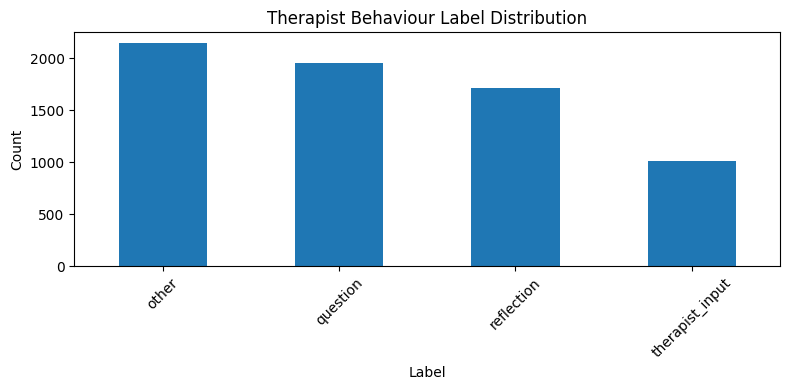

In [13]:
label_counts = therapist_df["main_therapist_behaviour"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
label_counts.plot(kind="bar")
plt.title("Therapist Behaviour Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Inspect transcript-level MI quality

In [14]:
if "mi_quality" in therapist_df.columns:
    print(therapist_df[["transcript_id", "mi_quality"]].drop_duplicates()["mi_quality"].value_counts(dropna=False))

mi_quality
high    110
low      23
Name: count, dtype: int64


Examples from each therapist behaviour class

In [15]:
labels = therapist_df["main_therapist_behaviour"].dropna().unique().tolist()

for label in sorted(labels):
    print(f"\n===== Examples: {label} =====")
    sample_rows = therapist_df[therapist_df["main_therapist_behaviour"] == label][["utterance_text"]].head(5)
    for i, txt in enumerate(sample_rows["utterance_text"], 1):
        print(f"{i}. {txt}")


===== Examples: other =====
1. Great. So, let's see how well you're doing with these new meds.
2. Okay.
3. Okay. Good.
4. Hi, Emily.
5. It's been a while.

===== Examples: question =====
1. Thanks for filling it out. We give this form to everyone once a year regardless of why they come in. It helps us provide better care. Is it okay if I take a look at what you put down?
2. Uh, what else can you tell me about your drinking.
3. Okay. So, can I share with you some information on alcohol use?
4. Yeah, you're surprised to hear that?
5. Well, how do you think your drinking relates to the depression you've experienced?

===== Examples: reflection =====
1. Right. By the way, binge drinking is defined for women as having more than, uh, three drinks and there are about five drinks in a bottle. So, you enjoy drinking wine because it helps make things, uh, a little bit more interesting when you're feeling down but at the same time you don't like drinking when you have more than you want it to an

## Create a compact modelling dataframe

In [16]:
model_df = therapist_df[[
    "transcript_id",
    "utterance_text",
    "main_therapist_behaviour"
]].copy()

model_df = model_df.rename(columns={
    "utterance_text": "text",
    "main_therapist_behaviour": "label"
})

print("Model dataframe shape:", model_df.shape)
display(model_df.head())

Model dataframe shape: (6826, 3)


,transcript_id,text,label
0,0,Thanks for filling it out. We give this form t...,question
2,0,"So, let's see. It looks that you put-- You dri...",therapist_input
4,0,-and you usually have three to four drinks whe...,therapist_input
6,0,Okay. That's at least 12 drinks a week.,therapist_input
8,0,"Okay. Just so you know, my role, um, when we t...",therapist_input


In [17]:
print("Unique labels:", sorted(model_df["label"].unique().tolist()))
print("\nNumber of transcripts:", model_df["transcript_id"].nunique())
print("Number of utterances:", len(model_df))
print("\nNulls:")
print(model_df.isna().sum())

Unique labels: ['other', 'question', 'reflection', 'therapist_input']

Number of transcripts: 133
Number of utterances: 6826

Nulls:
transcript_id    0
text             0
label            0
dtype: int64


In [19]:
output_path = "therapist_model_df.csv"
model_df.to_csv(output_path, index=False)

print(f"Saved cleaned file to: {output_path}")

Saved cleaned file to: therapist_model_df.csv


---

# II. Data Preprocessing

Prepare a clean therapist-utterance dataset for modelling.

In [20]:
# keep only necessary columns
prep_df = therapist_df[[
    "transcript_id",
    "utterance_text",
    "main_therapist_behaviour"
]].copy()

prep_df = prep_df.rename(columns={
    "utterance_text": "text",
    "main_therapist_behaviour": "label"
})

print(prep_df.shape)
prep_df.head()

(6826, 3)


,transcript_id,text,label
0,0,Thanks for filling it out. We give this form t...,question
2,0,"So, let's see. It looks that you put-- You dri...",therapist_input
4,0,-and you usually have three to four drinks whe...,therapist_input
6,0,Okay. That's at least 12 drinks a week.,therapist_input
8,0,"Okay. Just so you know, my role, um, when we t...",therapist_input


## Remove missing and duplicate rows

In [ ]:
prep_df = prep_df.dropna(subset=["text", "label"]).copy()
prep_df["text"] = prep_df["text"].astype(str).str.strip()
prep_df = prep_df[prep_df["text"] != ""].copy()

before_dedup = len(prep_df)
prep_df = prep_df.drop_duplicates(subset=["transcript_id", "text", "label"]).copy()

print("Before dedup:", before_dedup)
print("After dedup :", len(prep_df))

## Normalize text

In [23]:
import re

def clean_text(text):
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text

prep_df["text"] = prep_df["text"].apply(clean_text)

prep_df.head()

,transcript_id,text,label
0,0,Thanks for filling it out. We give this form t...,question
2,0,"So, let's see. It looks that you put-- You dri...",therapist_input
4,0,-and you usually have three to four drinks whe...,therapist_input
6,0,Okay. That's at least 12 drinks a week.,therapist_input
8,0,"Okay. Just so you know, my role, um, when we t...",therapist_input


In [29]:
# Inspect label distribution after cleaning
label_counts = prep_df["label"].value_counts()
label_counts

,count
label,
other,2143
question,1954
reflection,1717
therapist_input,1012


In [30]:
# valid_labels = label_counts[label_counts >= 20].index
# prep_df = prep_df[prep_df["label"].isin(valid_labels)].copy()

# print(prep_df["label"].value_counts())

## Encode labels

In [31]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
prep_df["label_id"] = label_encoder.fit_transform(prep_df["label"])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(label_mapping)

{'other': np.int64(0), 'question': np.int64(1), 'reflection': np.int64(2), 'therapist_input': np.int64(3)}


## Stratified train/validation/test split

In [32]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    prep_df,
    test_size=0.30,
    random_state=42,
    stratify=prep_df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

Train shape: (4778, 4)
Val shape  : (1024, 4)
Test shape : (1024, 4)


In [33]:
# Sanity check label balance across splits

print("Train label distribution:")
print(train_df["label"].value_counts(normalize=True).round(3))

print("\nValidation label distribution:")
print(val_df["label"].value_counts(normalize=True).round(3))

print("\nTest label distribution:")
print(test_df["label"].value_counts(normalize=True).round(3))

Train label distribution:
label
other              0.314
question           0.286
reflection         0.252
therapist_input    0.148
Name: proportion, dtype: float64

Validation label distribution:
label
other              0.313
question           0.286
reflection         0.252
therapist_input    0.148
Name: proportion, dtype: float64

Test label distribution:
label
other              0.314
question           0.286
reflection         0.251
therapist_input    0.148
Name: proportion, dtype: float64


In [34]:
X_train = train_df["text"].tolist()
y_train = train_df["label_id"].tolist()

X_val = val_df["text"].tolist()
y_val = val_df["label_id"].tolist()

X_test = test_df["text"].tolist()
y_test = test_df["label_id"].tolist()

print(len(X_train), len(X_val), len(X_test))

4778 1024 1024


In [35]:
train_df.to_csv("train_df.csv", index=False)
val_df.to_csv("val_df.csv", index=False)
test_df.to_csv("test_df.csv", index=False)

print("Saved: train_df.csv, val_df.csv, test_df.csv")

Saved: train_df.csv, val_df.csv, test_df.csv


---

# III. Baseline Models

Evaluate classical machine learning models using TF-IDF features.

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

## 3.1. TF-IDF vectorization

In [37]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train_vec = tfidf.fit_transform(train_df["text"])
X_test_vec = tfidf.transform(test_df["text"])

y_train = train_df["label_id"]
y_test = test_df["label_id"]

## 3.2. Logistic Regression baseline

In [38]:
lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train_vec, y_train)

y_pred_lr = lr_model.predict(X_test_vec)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.7236328125

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       322
           1       0.66      0.78      0.72       293
           2       0.68      0.63      0.65       257
           3       0.68      0.55      0.61       152

    accuracy                           0.72      1024
   macro avg       0.72      0.70      0.70      1024
weighted avg       0.73      0.72      0.72      1024



## 3.3. Linear SVM baseline

In [39]:
svm_model = LinearSVC()

svm_model.fit(X_train_vec, y_train)

y_pred_svm = svm_model.predict(X_test_vec)

print("Linear SVM Accuracy:")
print(accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy:
0.70703125

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.82       322
           1       0.68      0.74      0.71       293
           2       0.64      0.60      0.62       257
           3       0.62      0.56      0.59       152

    accuracy                           0.71      1024
   macro avg       0.69      0.68      0.69      1024
weighted avg       0.70      0.71      0.70      1024



## 3.4. Model Comparison

In [40]:
lr_acc = accuracy_score(y_test, y_pred_lr)
svm_acc = accuracy_score(y_test, y_pred_svm)

print("Model comparison:")
print("Logistic Regression:", lr_acc)
print("Linear SVM:", svm_acc)

Model comparison:
Logistic Regression: 0.7236328125
Linear SVM: 0.70703125


---

# IV. LLM-based Fidelity Classification

This section evaluates an embedding-based approach using Sentence-BERT representations of therapist utterances. These dense semantic embeddings are used as inputs to downstream classifiers for therapist behaviour prediction.

In [41]:
!pip -q install sentence-transformers

In [60]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

## 4.1. Load embedding model and encode text

In [43]:
# Load embedding model
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [44]:
# Encode text

X_train_emb = sbert_model.encode(
    train_df["text"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

X_test_emb = sbert_model.encode(
    test_df["text"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

y_train = train_df["label_id"].values
y_test = test_df["label_id"].values

print("Train embeddings shape:", X_train_emb.shape)
print("Test embeddings shape :", X_test_emb.shape)

Batches:   0%|          | 0/150 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Train embeddings shape: (4778, 384)
Test embeddings shape : (1024, 384)


## 4.2. SBERT + Logistic Regression

In [45]:
sbert_lr = LogisticRegression(max_iter=500)

sbert_lr.fit(X_train_emb, y_train)

y_pred_sbert_lr = sbert_lr.predict(X_test_emb)

print("SBERT + Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_sbert_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_sbert_lr, target_names=label_encoder.classes_))

SBERT + Logistic Regression Accuracy:
0.7822265625

Classification Report:
                 precision    recall  f1-score   support

          other       0.90      0.84      0.87       322
       question       0.78      0.83      0.81       293
     reflection       0.74      0.70      0.72       257
therapist_input       0.62      0.68      0.65       152

       accuracy                           0.78      1024
      macro avg       0.76      0.77      0.76      1024
   weighted avg       0.79      0.78      0.78      1024



## 4.3. SBERT + Linear SVM

In [46]:
sbert_svm = LinearSVC()

sbert_svm.fit(X_train_emb, y_train)

y_pred_sbert_svm = sbert_svm.predict(X_test_emb)

print("SBERT + Linear SVM Accuracy:")
print(accuracy_score(y_test, y_pred_sbert_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_sbert_svm, target_names=label_encoder.classes_))

SBERT + Linear SVM Accuracy:
0.76953125

Classification Report:
                 precision    recall  f1-score   support

          other       0.90      0.84      0.87       322
       question       0.76      0.84      0.80       293
     reflection       0.73      0.68      0.71       257
therapist_input       0.60      0.62      0.61       152

       accuracy                           0.77      1024
      macro avg       0.75      0.75      0.75      1024
   weighted avg       0.77      0.77      0.77      1024



## 4.4. Mixed model comparison

In [47]:
results = {
    "TF-IDF + Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "TF-IDF + Linear SVM": accuracy_score(y_test, y_pred_svm),
    "SBERT + Logistic Regression": accuracy_score(y_test, y_pred_sbert_lr),
    "SBERT + Linear SVM": accuracy_score(y_test, y_pred_sbert_svm),
}

print("Model Comparison")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")

Model Comparison
TF-IDF + Logistic Regression: 0.7236
TF-IDF + Linear SVM: 0.7070
SBERT + Logistic Regression: 0.7822
SBERT + Linear SVM: 0.7695


In [49]:
# Results table
results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values())
}).sort_values("Accuracy", ascending=False)

results_df

,Model,Accuracy
2,SBERT + Logistic Regression,0.782227
3,SBERT + Linear SVM,0.769531
0,TF-IDF + Logistic Regression,0.723633
1,TF-IDF + Linear SVM,0.707031


In [50]:
# Save results
results_df.to_csv("baseline_vs_sbert_results.csv", index=False)
print("Saved: baseline_vs_sbert_results.csv")

Saved: baseline_vs_sbert_results.csv


---

# V. Evaluation and Error Analysis

This section evaluates model performance in more detail using confusion matrices and per-class metrics.
We also inspect misclassified therapist utterances to better understand model limitations.

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## 5.1. Confusion matrix for best model

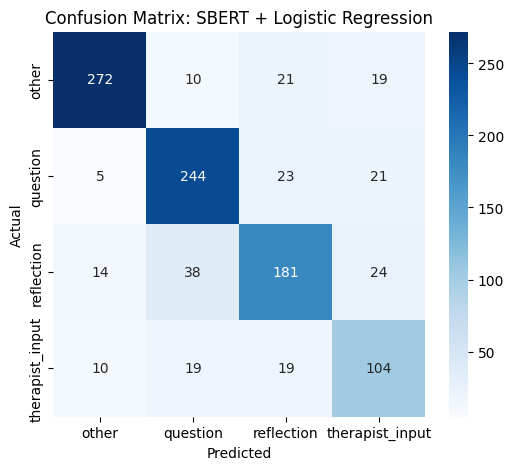

In [52]:
# Pick the best performing model from Part IV

cm = confusion_matrix(y_test, y_pred_sbert_lr)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: SBERT + Logistic Regression")
plt.show()

## 5.2. Classification report table

In [63]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    y_pred_sbert_lr,
    target_names=label_encoder.classes_,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
other,0.903654,0.844720,0.873194,322.000000
question,0.784566,0.832765,0.807947,293.000000
reflection,0.741803,0.704280,0.722555,257.000000
therapist_input,0.619048,0.684211,0.650000,152.000000
accuracy,0.782227,0.782227,0.782227,0.782227
macro avg,0.762268,0.766494,0.763424,1024.000000
weighted avg,0.786712,0.782227,0.783588,1024.000000


In [56]:
# # Save evaluation results
# report_df.to_csv("classification_report_sbert_lr.csv")
# print("Saved evaluation report")

## 5.3. Inspect and analize misclassified or error examples

This part is mportant for thesis discussion.

In [64]:
test_df = test_df.copy()
test_df["pred_label_id"] = y_pred_sbert_lr
test_df["pred_label"] = label_encoder.inverse_transform(test_df["pred_label_id"])

errors_df = test_df[test_df["label"] != test_df["pred_label"]]

print("Number of errors:", len(errors_df))
errors_df.head(10)

Number of errors: 223


,transcript_id,text,label,label_id,pred_label_id,pred_label
4174,55,So it sounds like you have two goals right now...,reflection,2,1,question
177,4,Yeah. There's certainly been-- There's no prob...,reflection,2,1,question
13182,126,"Well, some of the common ones are nausea, vomi...",therapist_input,3,1,question
5426,56,"-and, uh, and-and also might help you organize...",question,1,3,therapist_input
9306,98,"Right, so you make--",other,0,2,reflection
11525,121,"Yeah, I sense that. I sense that in you that y...",reflection,2,0,other
10401,110,-or just local?,question,1,0,other
2649,36,Right. I know you've been seeing Dr. Brown abo...,other,0,2,reflection
12325,15,Can I help you?,question,1,0,other
3223,45,"That's okay. Well, I know that you are making ...",other,0,3,therapist_input


In [58]:
# Show error examples
for i, row in errors_df.sample(10, random_state=42).iterrows():
    print("TEXT:", row["text"])
    print("TRUE:", row["label"])
    print("PRED:", row["pred_label"])
    print("-"*60)

TEXT: I'm really glad you did too. I really appreciate it because that's the only way that we can work together-
TRUE: reflection
PRED: other
------------------------------------------------------------
TEXT: Yeah. Takes a lot. Takes a lot. And you're the only one that'll- that can know what it is you're willing to work through that fear for.
TRUE: other
PRED: reflection
------------------------------------------------------------
TEXT: Well, it's very much up to you, you're the boss of your own life. Where would you like to start?
TRUE: question
PRED: reflection
------------------------------------------------------------
TEXT: That's okay. Well, I know that you are making an effort. I do appreciate then and when-when I do stop by that you still sign the paperwork even though you feel like it's annoying at times. So, thank you for, uh, at least doing that.
TRUE: other
PRED: therapist_input
------------------------------------------------------------
TEXT: You like to have a good time?

In [59]:
# Class-wise error counts
errors_df["label"].value_counts()

,count
label,
reflection,82
therapist_input,57
other,51
question,46
